# Handwritten Digit Recognition

Classifying digits 0-9 using Random Forest and SVM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('white')
%matplotlib inline


In [2]:
digits = load_digits()
digits.data.shape, digits.images[0].shape


((1797, 64), (8, 8))

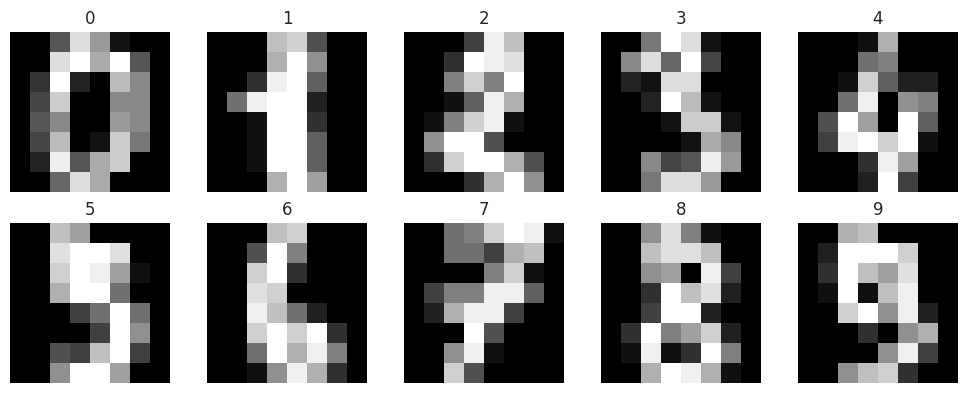

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap='gray')
    ax.set_title(f"{label}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('digits_samples.png', bbox_inches='tight', dpi=120)
plt.show()


In [4]:
X = digits.data / 16.0
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svm = SVC(kernel='rbf', gamma='scale')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


In [6]:
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest accuracy: 0.9638888888888889
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



In [7]:
print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM accuracy: 0.9916666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       1.00      0.94      0.97        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



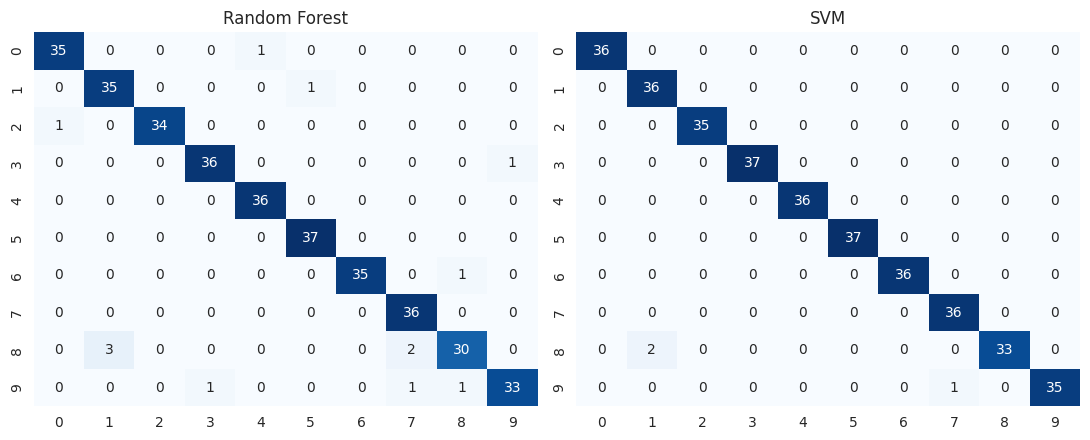

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_svm], ['Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig('digits_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


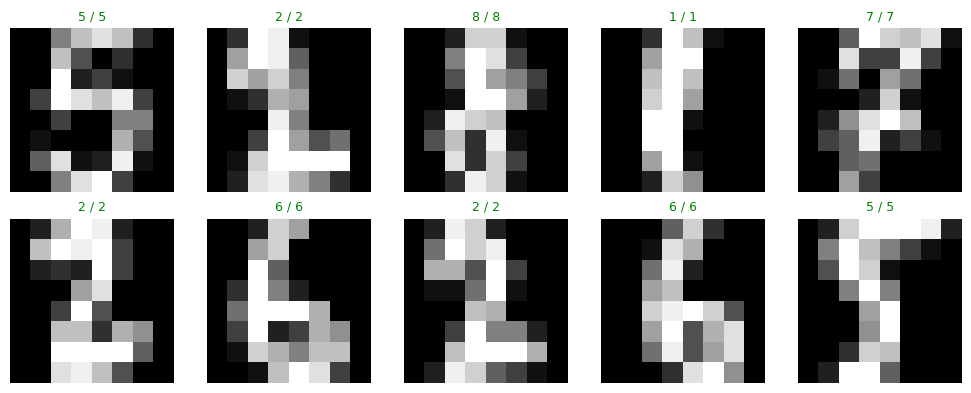

In [9]:
X_test_images = X_test.reshape(-1, 8, 8)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_images[i], cmap='gray')
    correct = y_pred_svm[i] == y_test[i]
    ax.set_title(f"{y_pred_svm[i]} / {y_test[i]}", color='green' if correct else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('digits_predictions.png', bbox_inches='tight', dpi=120)
plt.show()
